# Import et Configuration

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")

RANDOM_STATE = 42

PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data" / "raw"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

Cette gestion des chemins est préférable à un chemin absolu car cela risque d'empêcher une autre personne d'exécuter facilement le projet.

# Chargement du jeu de donnée

In [2]:
train_path = DATA_DIR / "train.csv"
test_path = DATA_DIR / "test.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print(f"Train shape : {train_df.shape}")
print(f"Test shape: {test_df.shape}")

train_df.head()

Train shape : (891, 12)
Test shape: (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# Vérification intiales

In [3]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [4]:
train_df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PassengerId,891.0,NaN,NaN,NaN,446.0,257.353842,1.0,223.5,446.0,668.5,891.0
Survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
Pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
Name,891,891,"Braund, Mr. Owen Harris",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
SibSp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
Parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
Ticket,891,681,347082,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292


In [5]:
print("Nombre de doublons :", train_df.duplicated().sum())

Nombre de doublons : 0


In [6]:
missing_values = (
    train_df.isna()
    .sum()
    .to_frame(name="missing_count")
    .assign(
        missing_rate=lambda df: (
            100 * df["missing_count"] / len(train_df)
        ).round(2)
    )
    .sort_values("missing_rate", ascending=False)
)

missing_values

,missing_count,missing_rate
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22
PassengerId,0,0.00
Name,0,0.00
Pclass,0,0.00
Survived,0,0.00
Sex,0,0.00
Parch,0,0.00
SibSp,0,0.00


# Contrôle de la cible

In [7]:
train_df["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [8]:
target_distribution = (
    train_df["Survived"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

target_distribution

Survived
0    61.62
1    38.38
Name: proportion, dtype: float64

### Visualisation

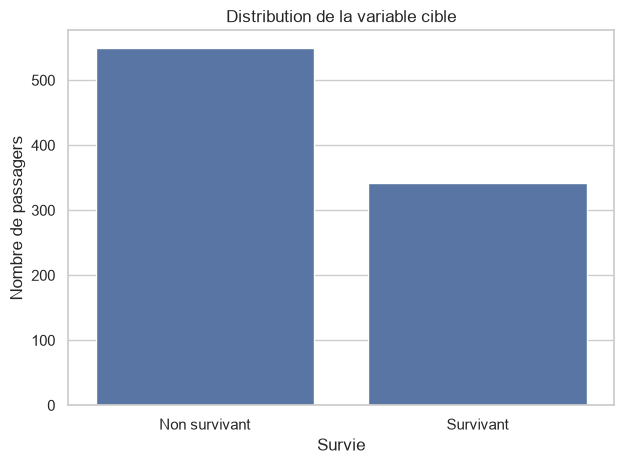

In [9]:
ax = sns.countplot(data=train_df, x="Survived")

ax.set(
    title="Distribution de la variable cible",
    xlabel="Survie",
    ylabel="Nombre de passagers"
)

ax.set_xticks([0, 1])
ax.set_xticklabels(["Non survivant", "Survivant"])

plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "target_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# Premières questions d'analyse

On va commencer par regarder le taux et le nombre de survivant selon le sexe de chaque passager

In [10]:
train_df.groupby("Sex")["Survived"].agg(["mean", "count"])

,mean,count
Sex,,
female,0.742038,314
male,0.188908,577


On regarde ensuite le taux et le nombre de survivant selon les différentes classes des passagers 

In [11]:
train_df.groupby("Pclass")["Survived"].agg(["mean", "count"])

,mean,count
Pclass,,
1,0.629630,216
2,0.472826,184
3,0.242363,491


On va venir le voir sous forme de tableau croisée

In [12]:
train_df.groupby(["Sex", "Pclass"])["Survived"].agg(["mean", "count"])

mean  count
Sex    Pclass                 
female 1       0.968085     94
       2       0.921053     76
       3       0.500000    144
male   1       0.368852    122
       2       0.157407    108
       3       0.135447    347

sous forme de graphique on a

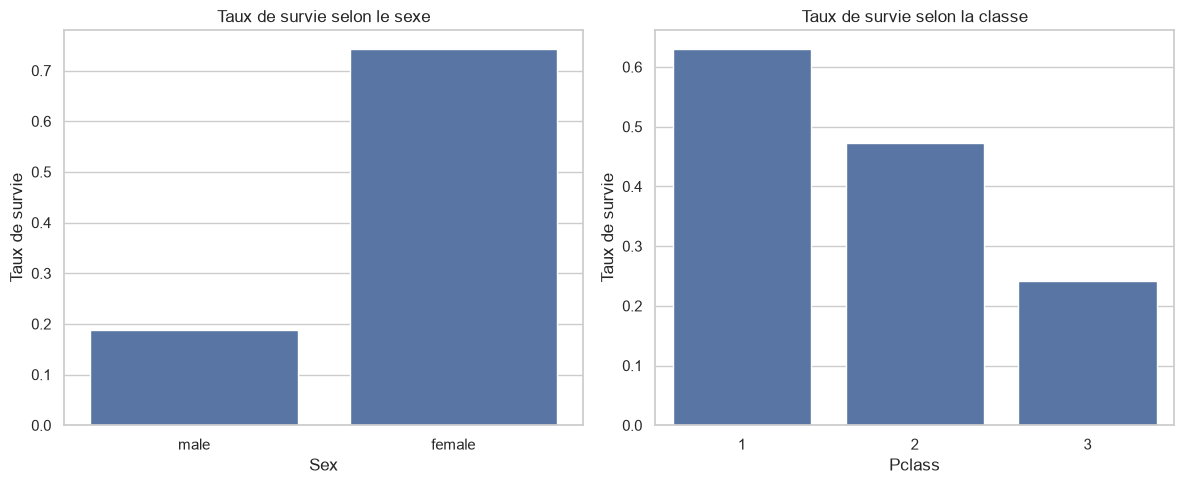

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(
    data=train_df,
    x="Sex",
    y="Survived",
    errorbar=None,
    ax=axes[0]
)
axes[0].set_title("Taux de survie selon le sexe")
axes[0].set_ylabel("Taux de survie")

sns.barplot(
    data=train_df,
    x="Pclass",
    y="Survived",
    errorbar=None,
    ax=axes[1]
)
axes[1].set_title("Taux de survie selon la classe")
axes[1].set_ylabel("Taux de survie")

plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "survival_by_sex_and_class.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

on va venir voir le graphique pour la distribution de l'âge

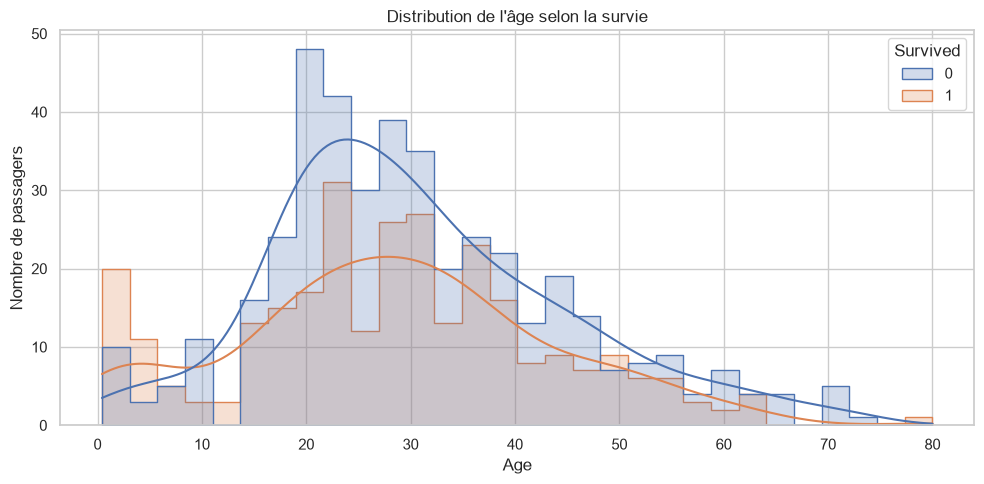

In [14]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=train_df,
    x="Age",
    hue="Survived",
    bins=30,
    kde=True,
    element="step"
)

plt.title("Distribution de l'âge selon la survie")
plt.xlabel("Age")
plt.ylabel("Nombre de passagers")

plt.tight_layout()
plt.show()

### Interprétation
On constate que le taux de survie semblre plus élevé chez les femmes que chez les hommes. Que la classe du billet semble également associée à la survie, les passagers de premières classe présentant un taux de survie supérieur. Ces résultats restent descriptif et ne permettent pas, à eux seuls, d'établir une relation causale.

# Préparation des données pour l'analyse exploratoire

Une copie du jeu d'entraînement est créée afin d'ajouter des libellés et des variables exploratoires sans modifier les données brutes. Ces transformations servent uniquement à faciliter les visualisations et ne constituent par encore la pipeline de prétraitement du modèle.

In [15]:
eda_df = train_df.copy()

eda_df["Survived_label"] = eda_df["Survived"].map({
    0: "Non survivant",
    1: "Survivant"
})

eda_df["Pclass_label"] = eda_df["Pclass"].map({
    1: "1re classe",
    2: "2e classe",
    3: "3e classe"
})

eda_df["Sex_label"] = eda_df["Sex"].map({
    "female": "Femme",
    "male": "Homme"
})

eda_df["Embarked_label"] = eda_df["Embarked"].map({
    "C": "Cherbourg",
    "Q": "Queenstown",
    "S": "Southampton"
})

eda_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Survived_label,Pclass_label,Sex_label,Embarked_label
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Non survivant,3e classe,Homme,Southampton
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Survivant,1re classe,Femme,Cherbourg
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Survivant,3e classe,Femme,Southampton
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Survivant,1re classe,Femme,Southampton
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Non survivant,3e classe,Homme,Southampton


## Analayse des valeurs manquantes

Les valeurs manquantes sont étudiées séparément dans les jeux d'entraînement et de test. Cette étape permet d'anticiper les transformations qui devront être intégrées dans le future pipeline de prétraitement.

In [16]:
def missing_values_table(dataframe):
    missing_count = dataframe.isna().sum()
    missing_rate = 100 * missing_count / len(dataframe)
    
    return (
        pd.DataFrame({
            "missing_count": missing_count,
            "missing_rate": missing_rate
        })
        .query("missing_count > 0")
        .sort_values("missing_rate", ascending=False)
        .round(2)
    )
    
traint_missing = missing_values_table(train_df)
test_missing = missing_values_table(test_df)

print("Valeurs manquantes dans le jeu d'entraînement :")
display(traint_missing)

print("Valeurs manquantes dans le jeu de test :")
display(test_missing)

Valeurs manquantes dans le jeu d'entraînement :


,missing_count,missing_rate
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22


Valeurs manquantes dans le jeu de test :


,missing_count,missing_rate
Cabin,327,78.23
Age,86,20.57
Fare,1,0.24


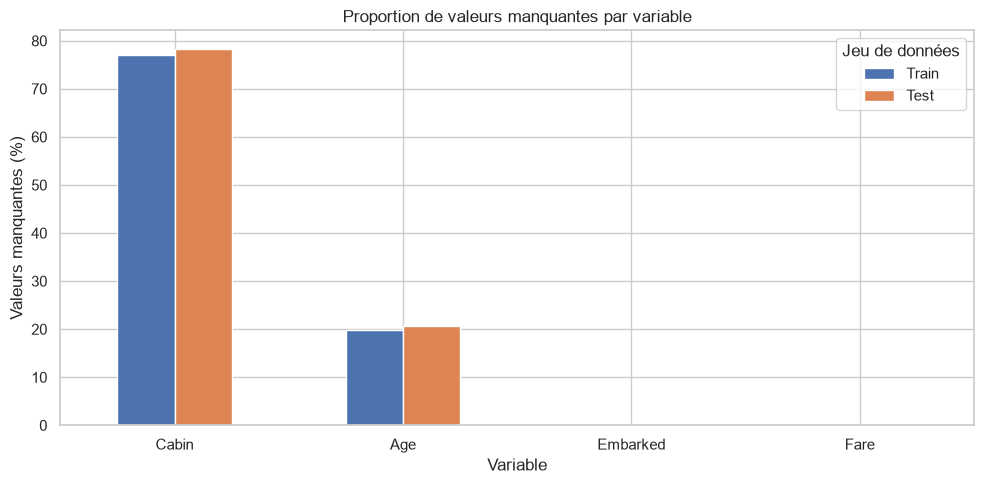

In [17]:
missing_comparison = pd.concat(
    [
        train_df.isna().mean().mul(100).rename("Train"),
        test_df.isna().mean().mul(100).rename("Test")
    ],
    axis=1
)

missing_comparison = (
    missing_comparison
    .query("Train > 0 or Test > 0")
    .sort_values("Train", ascending=False)
)

ax = missing_comparison.plot(
    kind="bar",
    figsize=(10, 5),
    color=["#4C72B0", "#DD8452"]
)

ax.set(
    title="Proportion de valeurs manquantes par variable",
    xlabel="Variable",
    ylabel="Valeurs manquantes (%)"
)

ax.legend(title="Jeu de données")

plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "missing_values_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

On constate que la variable `Cabin` présente une proportion très élevée de valeurs manquantes, proche de $77\%$ dans le jeu d'entraînement. La variable `Age` comporte également environ $20\%$ de valeurs absentes. Enfin, seules deux observations du jeu d'entraînement ne contiennent pas de port d'embarquement.

Le jeu de test contient aussi des âges et des cabines manquants, ainsi qu'une valeur manquante pour `Fare`. Ces absences devront être gérées par un pipeline afin que les mêmes transformations soient appliquées aux données d'entraînement et de test.

La colonne `Cabin` ne devra pas nécessairement être supprimée immédiatement : le pont ou la simple disponibilité d'une cabine pourraient contenir de l'information utile.

# Fonction utilitaires pour la présentation du taux de survie

In [18]:
def survival_summary(dataframe: pd.DataFrame, group_column: str) -> pd.DataFrame:
    summary: pd.DataFrame = (
        dataframe
        .groupby(group_column, dropna=False)
        .agg(
            nombre_passagers=("Survived", "size"),
            nombre_survivants=("Survived", "sum"),
            taux_survie=("Survived", "mean")
        )
        .sort_values("taux_survie", ascending=False)
    )
    
    summary["taux_survie"] = (
        summary["taux_survie"]
        .mul(100)
        .round(2)
    )
    
    return summary

pour annoter les graphiques

In [19]:
def add_percentage_labels(ax):
    for container in ax.containers:
        labels = [
            f"{bar.get_height():.1%}"
            if not np.isnan(bar.get_height())
            else ""
            for bar in container
        ]
        
        ax.bar_label(
            container,
            labels=labels,
            padding=3,
            fontsize=9
        )

## Survie selon le sexe
Nous étudions si le taux de survie varie selon le sexe des passagers.

In [20]:
survival_by_sex = survival_summary(eda_df, "Sex_label")
survival_by_sex

,nombre_passagers,nombre_survivants,taux_survie
Sex_label,,,
Femme,314,233,74.20
Homme,577,109,18.89


visualisation

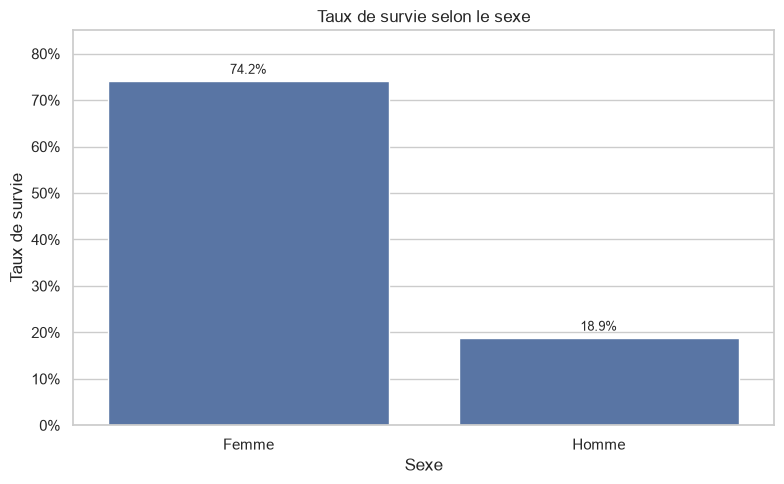

In [21]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=eda_df,
    x="Sex_label",
    y="Survived",
    order=["Femme", "Homme"],
    errorbar=None,
    color="#4C72B0"
)

ax.set(
    title="Taux de survie selon le sexe",
    xlabel="Sexe",
    ylabel="Taux de survie"
)

ax.set_ylim(0, 0.85)
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda value, _: f"{value:.0%}")
)

add_percentage_labels(ax)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "survival_by_sex.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Le sexe est fortement associé à la survie. Environ $74\%$ des femmes ont survécu, contre seulement $19\%$ des hommes. Cet écart est cohérent avec les règle d'évacuation souvent résumée par "les femmes et les enfants d'abord".

Cette observation suggère que `Sex` consituera probablement l'une des variables les plus prédictives. Elle reste néamoins descriptive et ne suffit pas à établir une relation causale indépendante des autres caractéristiques.

## Survie selon la classe du billet

La classe du billet peut refléter à la fois la position du passager dans le navire et son statut socio-économique. On comparera les taux de survie des trois classes.

In [22]:
survival_by_class = survival_summary(eda_df, "Pclass")
survival_by_class.sort_index()

,nombre_passagers,nombre_survivants,taux_survie
Pclass,,,
1,216,136,62.96
2,184,87,47.28
3,491,119,24.24


visualisation

C:\Users\hoare\AppData\Local\Temp\ipykernel_29064\2162406544.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(["1re classe", "2e classe", "3e classe"])


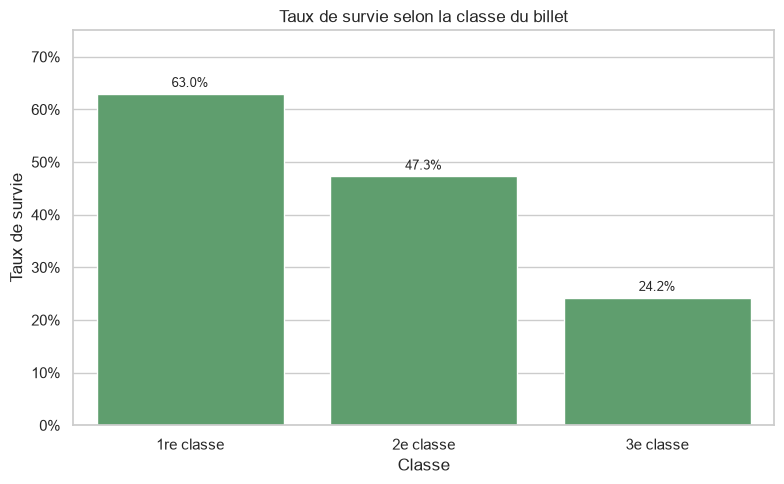

In [23]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=eda_df,
    x="Pclass",
    y="Survived",
    order=[1, 2, 3],
    errorbar=None,
    color="#55A868"
)

ax.set(
    title="Taux de survie selon la classe du billet",
    xlabel="Classe",
    ylabel="Taux de survie"
)

ax.set_xticklabels(["1re classe", "2e classe", "3e classe"])
ax.set_ylim(0, 0.75)

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda value, _: f"{value:.0%}")
)

add_percentage_labels(ax)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "survival_by_class.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Le taux de survie diminue avec la classe du billet. Il est d'environ 63 % en première
classe, 47 % en deuxième classe et 24 % en troisième classe.

La classe semble donc fortement associée à la survie. Cette différence pourrait
notamment être liée à la localisation des cabines, à l'accès aux canots de sauvetage
ou à d'autres facteurs socio-économiques.


## Interaction entre le sexe et la classe

Les analyses précédentes montrent que le sexe et la classe sont tous les deux associés
à la survie. Nous les étudions maintenant conjointement afin de déterminer si la
différence entre les femmes et les hommes est similaire dans toutes les classes.

In [24]:
sex_class_summary = (
    eda_df
    .groupby(["Pclass_label", "Sex_label"])
    .agg(
        nombre_passagers=("Survived", "size"),
        taux_survie=("Survived", "mean")
    )
)

sex_class_summary["taux_survie"] = (
    sex_class_summary["taux_survie"]
    .mul(100)
    .round(2)
)

sex_class_summary

nombre_passagers  taux_survie
Pclass_label Sex_label                               
1re classe   Femme                    94        96.81
             Homme                   122        36.89
2e classe    Femme                    76        92.11
             Homme                   108        15.74
3e classe    Femme                   144        50.00
             Homme                   347        13.54

C:\Users\hoare\AppData\Local\Temp\ipykernel_29064\3593550981.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(["1re classe", "2e classe", "3e classe"])


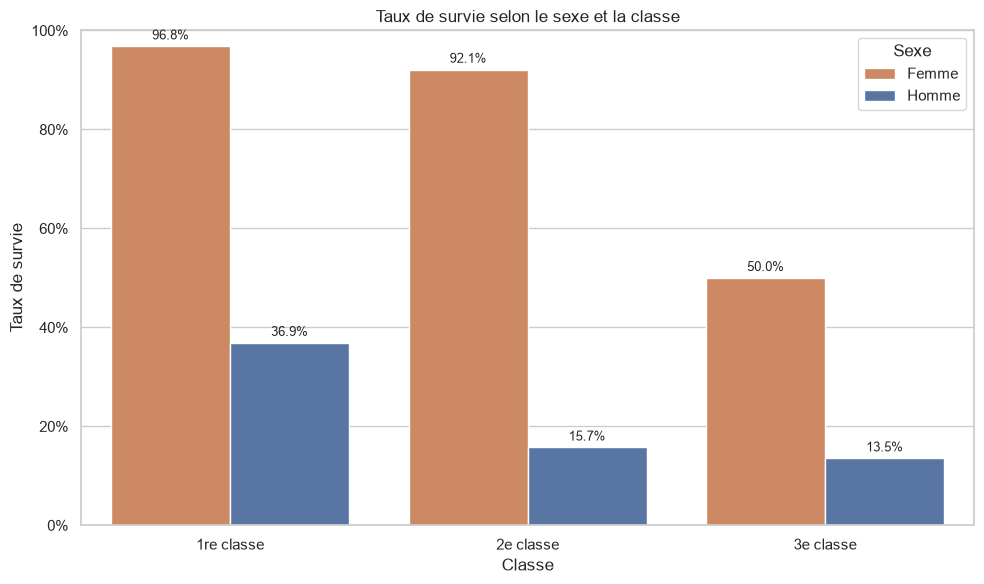

In [25]:
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=eda_df,
    x="Pclass",
    y="Survived",
    hue="Sex_label",
    order=[1,2,3],
    hue_order=["Femme", "Homme"],
    errorbar=None,
    palette=["#DD8452", "#4C72B0"]
)

ax.set(
    title="Taux de survie selon le sexe et la classe",
    xlabel="Classe",
    ylabel="Taux de survie"
)

ax.set_xticklabels(["1re classe", "2e classe", "3e classe"])
ax.set_ylim(0, 1)

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda value, _: f"{value:.0%}")
)

ax.legend(title="Sexe")
add_percentage_labels(ax)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "survival_by_sex_and_class.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

##### Heatmap complémentaire

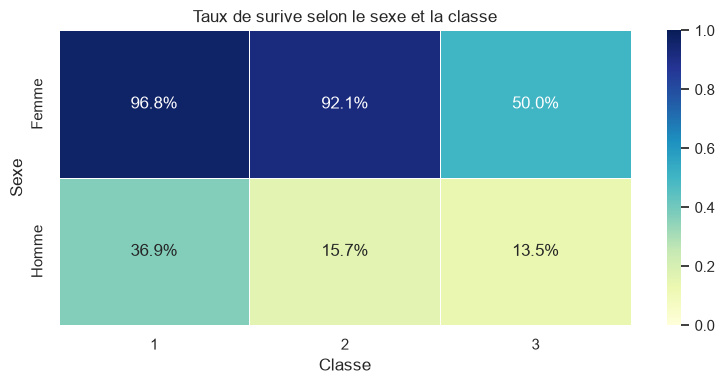

In [26]:
sex_class_pivot = eda_df.pivot_table(
    index="Sex_label",
    columns="Pclass",
    values="Survived",
    aggfunc="mean"
)

sex_class_pivot = sex_class_pivot.reindex(
    index=["Femme", "Homme"],
    columns=[1,2,3]
)

plt.figure(figsize=(8, 4))

sns.heatmap(
    sex_class_pivot,
    annot=True,
    fmt=".1%",
    cmap="YlGnBu",
    vmin=0,
    vmax=1,
    linewidths=0.5
)

plt.title("Taux de surive selon le sexe et la classe")
plt.xlabel("Classe")
plt.ylabel("Sexe")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "survival_heatmap_sex_class.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Le sexe reste fortement associé à la survie dans les trois classes, mais la classe
module également les résultats. Les femmes de première et de deuxième classe
présentent les taux de survie les plus élevés, tandis que les hommes de deuxième et de
troisième classe présentent des taux particulièrement faibles.

Cette analyse suggère qu'une interaction entre `Sex` et `Pclass` pourrait être utile
pour la prédiction. Les modèles non linéaires pourront apprendre automatiquement une
partie de cette interaction, tandis qu'elle pourrait être ajoutée explicitement à un
modèle linéaire.

---

## Analyse de l'âge

In [27]:
age_summary = (
    eda_df
    .groupby("Survived_label")["Age"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .round(2)
)

age_summary

,count,mean,median,std,min,max
Survived_label,,,,,,
Non survivant,424,30.63,28.0,14.17,1.00,74.0
Survivant,290,28.34,28.0,14.95,0.42,80.0


### Création de catégories d'âge

In [28]:
age_bins = [0, 12, 18, 30, 45, 60, np.inf]

age_labels = [
    "Enfant",
    "Adolescent",
    "Jeune adulte",
    "Adulte",
    "Adulte agé",
    "Senior"
]

eda_df["Age_group"] = pd.cut(
    eda_df["Age"],
    bins=age_bins,
    labels=age_labels,
    include_lowest=True
)

#### Tableau

In [29]:
age_group_summary = survival_summary(eda_df, "Age_group")
age_group_summary

,nombre_passagers,nombre_survivants,taux_survie
Age_group,,,
Enfant,69,40,57.97
Adolescent,70,30,42.86
Adulte,202,86,42.57
Adulte agé,81,33,40.74
Jeune adulte,270,96,35.56
NaN,177,52,29.38
Senior,22,5,22.73


#### Visualisation

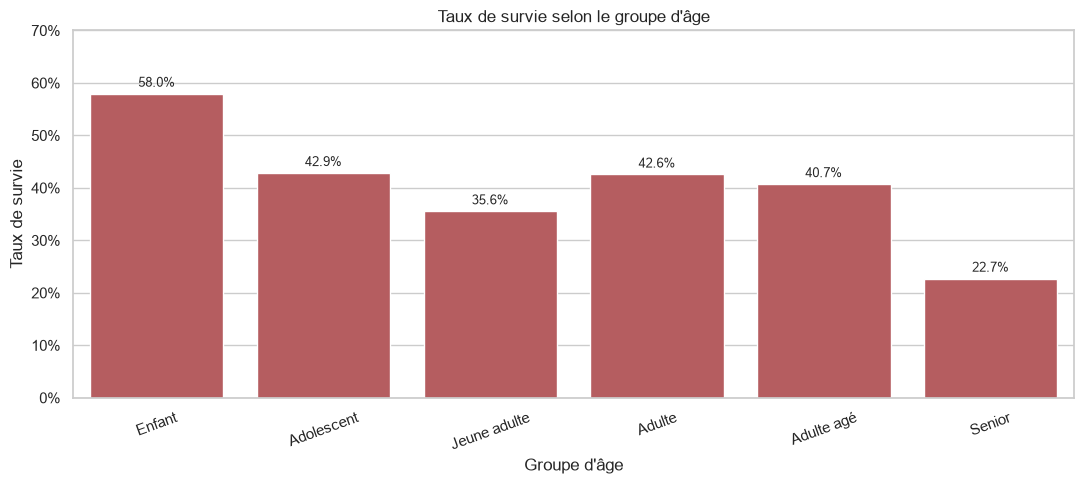

In [30]:
plt.figure(figsize=(11, 5))

ax = sns.barplot(
    data=eda_df,
    x="Age_group",
    y="Survived",
    order=age_labels,
    errorbar=None,
    color="#C44E52"
)

ax.set(
    title="Taux de survie selon le groupe d'âge",
    xlabel="Groupe d'âge",
    ylabel="Taux de survie"
)

ax.set_ylim(0, 0.7)
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda value, _: f"{value:.0%}")
)

plt.xticks(rotation=20)
add_percentage_labels(ax)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "survival_by_age_group.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Conclusion

Les distributions d'âge des survivants et des non-survivants se chevauchent fortement,
ce qui indique que l'âge seul ne permet pas de séparer clairement les deux groupes.
Les enfants semblent néanmoins présenter un taux de survie supérieur à plusieurs
catégories adultes.

Environ 20 % des âges sont manquants. Une imputation sera donc nécessaire dans le
pipeline. L'âge pourra être conservé comme variable numérique continue ; la création
de groupes d'âge sera éventuellement testée comme étape de feature engineering.

---

## Analyse du tarif

Le tarif du billet constitue une mesure indirecte du niveau socio-économique et du type
de réservation. Sa distribution et sa relation avec la survie sont analysées.

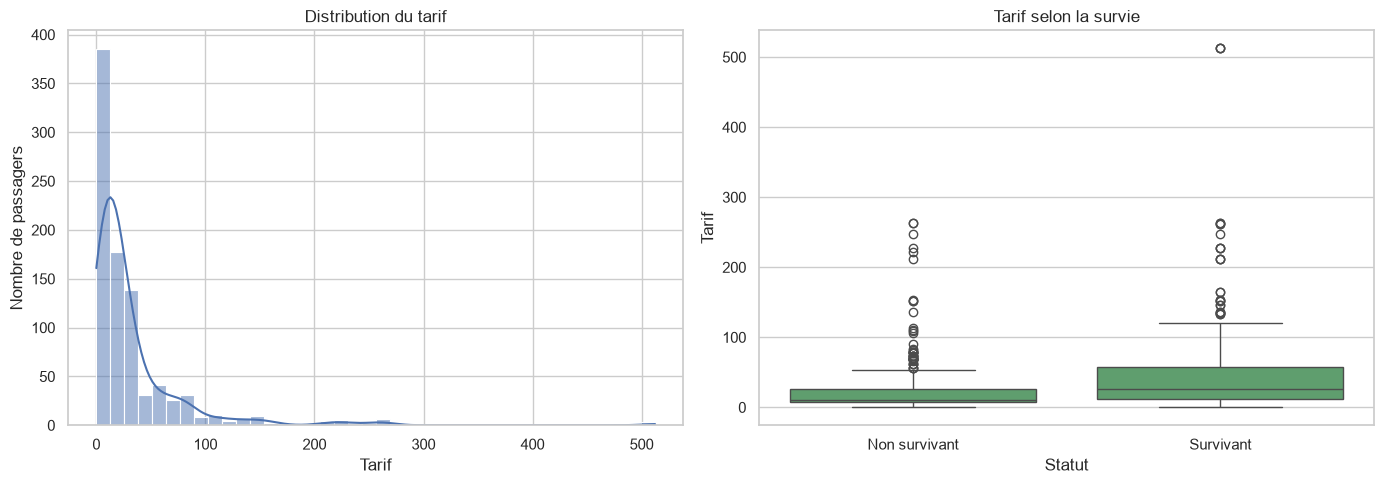

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    data=eda_df,
    x="Fare",
    bins=40,
    kde=True,
    ax=axes[0],
    color="#4C72B0"
)

axes[0].set(
    title="Distribution du tarif",
    xlabel="Tarif",
    ylabel="Nombre de passagers"
)

sns.boxplot(
    data=eda_df,
    x="Survived_label",
    y="Fare",
    order=["Non survivant", "Survivant"],
    ax=axes[1],
    color="#55A868"
)

axes[1].set(
    title="Tarif selon la survie",
    xlabel="Statut",
    ylabel="Tarif"
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "fare_distribution_and_survival.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


#### Transformation logarithmique pour la visualisation

On applique une transformation logarithmique par rapport à la valeur extrême

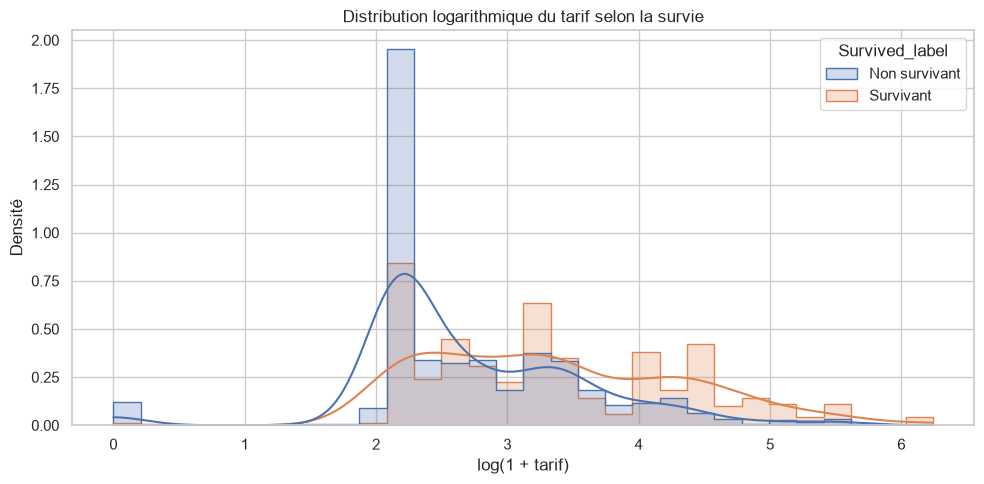

In [32]:
eda_df["LogFare"] = np.log1p(eda_df["Fare"])

plt.figure(figsize=(10, 5))

sns.histplot(
    data=eda_df,
    x="LogFare",
    hue="Survived_label",
    hue_order=["Non survivant", "Survivant"],
    bins=30,
    kde=True,
    element="step",
    stat="density",
    common_norm=False
)

plt.title("Distribution logarithmique du tarif selon la survie")
plt.xlabel("log(1 + tarif)")
plt.ylabel("Densité")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "log_fare_distribution_by_survival.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Statistiques

In [33]:
fare_summary = (
    eda_df
    .groupby("Survived_label")["Fare"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .round(2)
)

fare_summary

,count,mean,median,std,min,max
Survived_label,,,,,,
Non survivant,549,22.12,10.5,31.39,0.0,263.00
Survivant,342,48.40,26.0,66.60,0.0,512.33


#### Conclusion

La distribution de `Fare` est fortement asymétrique à droite : la majorité des
passagers ont payé un tarif relativement faible, tandis que quelques observations
présentent des montants très élevés.

Les survivants semblent avoir payé, en moyenne et en médiane, des tarifs plus élevés.
Cette relation est toutefois partiellement liée à la classe du billet. Une
transformation logarithmique pourra être testée afin de réduire l'influence des valeurs
extrêmes, notamment pour les modèles linéaires.

---

## Analyse du port d'embarquement

In [34]:
embarked_summary = survival_summary(eda_df, "Embarked_label")
embarked_summary

,nombre_passagers,nombre_survivants,taux_survie
Embarked_label,,,
NaN,2,2,100.00
Cherbourg,168,93,55.36
Queenstown,77,30,38.96
Southampton,644,217,33.70


#### Visualisation

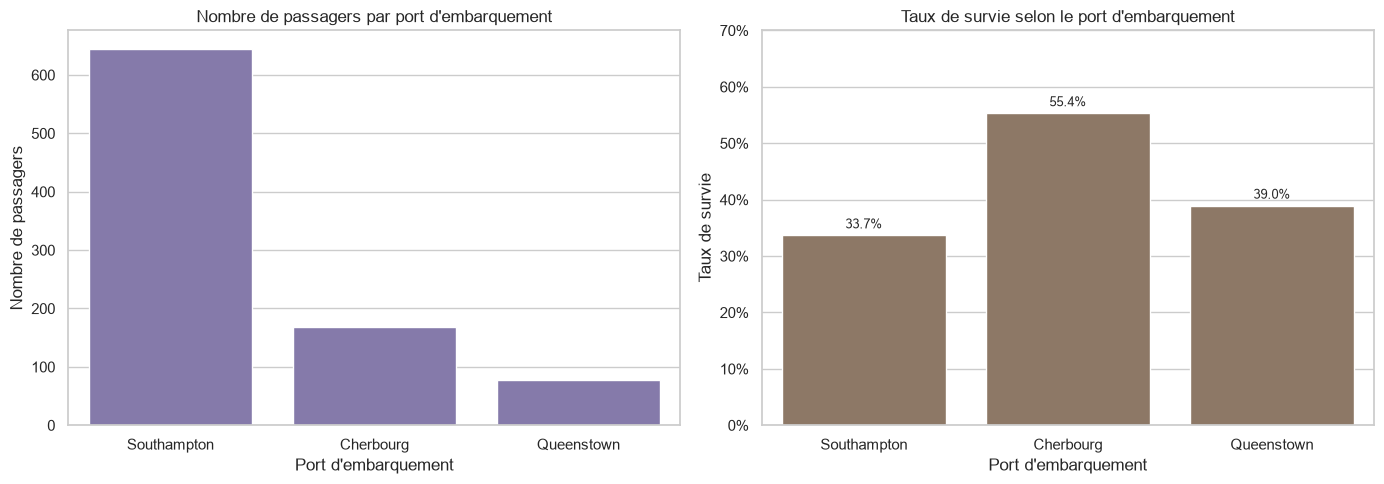

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(
    data=eda_df,
    x="Embarked_label",
    order=["Southampton", "Cherbourg", "Queenstown"],
    color="#8172B2",
    ax=axes[0]
)

axes[0].set(
    title="Nombre de passagers par port d'embarquement",
    xlabel="Port d'embarquement",
    ylabel="Nombre de passagers"
)

sns.barplot(
    data=eda_df,
    x="Embarked_label",
    y="Survived",
    order=["Southampton", "Cherbourg", "Queenstown"],
    errorbar=None,
    color="#937860",
    ax=axes[1]
)

axes[1].set(
    title="Taux de survie selon le port d'embarquement",
    xlabel="Port d'embarquement",
    ylabel="Taux de survie"
)

axes[1].set_ylim(0, 0.7)
axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda value, _: f"{value:.0%}")
)

add_percentage_labels(axes[1])

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "embarked_analysis.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Conclusion

La majorité des passagers ont embarqué à Southampton. Le taux de survie est plus élevé
parmi les passagers ayant embarqué à Cherbourg.

Cette différence ne doit pas être interprétée isolément : le port d'embarquement peut
être associé à la classe du billet et au tarif payé. Les deux valeurs manquantes de
`Embarked` pourront être imputées par la modalité la plus fréquente dans le pipeline.


In [36]:
embarked_class_table = pd.crosstab(
    eda_df["Embarked_label"],
    eda_df["Pclass_label"],
    normalize="index"
).mul(100).round(1)

embarked_class_table

Pclass_label,1re classe,2e classe,3e classe
Embarked_label,,,
Cherbourg,50.6,10.1,39.3
Queenstown,2.6,3.9,93.5
Southampton,19.7,25.5,54.8


---

## Influence de la composition familiale

Les variables `SibSp` et `Parch` sont combinées afin de représenter le nombre total de
membres de la famille présents à bord, passager inclus.

In [37]:
eda_df["FamilySize"] = (
    eda_df["SibSp"]
    + eda_df["Parch"]
    + 1
)

eda_df["IsAlone"] = np.where(
    eda_df["FamilySize"] == 1,
    "Seul",
    "Accompagné"
)

In [38]:
family_size_summary = survival_summary(eda_df, "FamilySize")
family_size_summary.sort_index()

,nombre_passagers,nombre_survivants,taux_survie
FamilySize,,,
1,537,163,30.35
2,161,89,55.28
3,102,59,57.84
4,29,21,72.41
5,15,3,20.00
6,22,3,13.64
7,12,4,33.33
8,6,0,0.00
11,7,0,0.00


#### Visualisation par taille exacte

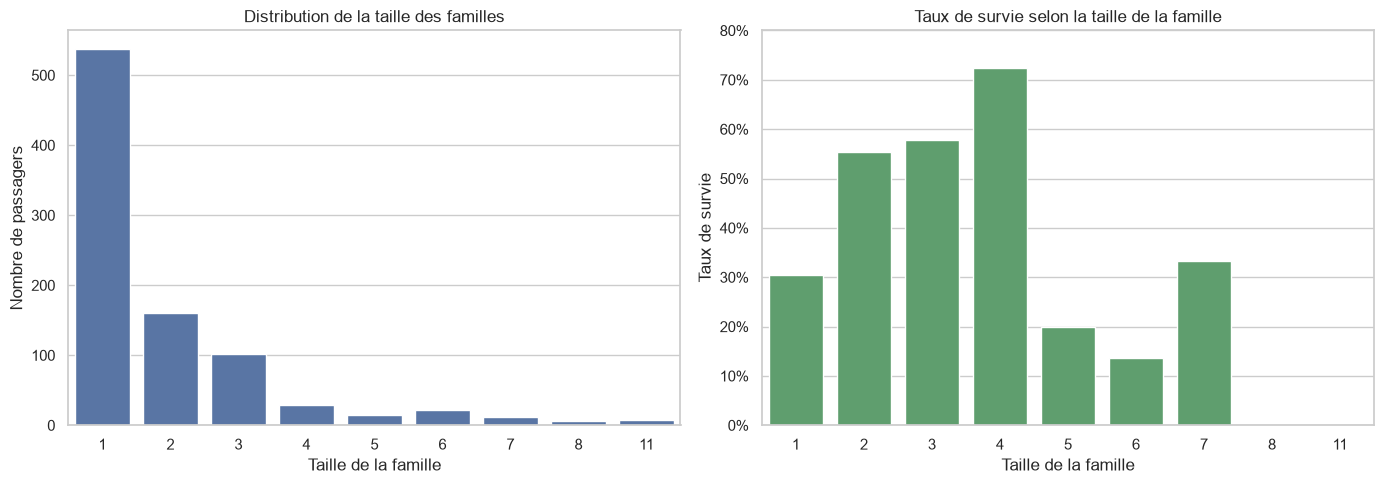

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(
    data=eda_df,
    x="FamilySize",
    color="#4C72B0",
    ax=axes[0]
)

axes[0].set(
    title="Distribution de la taille des familles",
    xlabel="Taille de la famille",
    ylabel="Nombre de passagers"
)

sns.barplot(
    data=eda_df,
    x="FamilySize",
    y="Survived",
    errorbar=None,
    color="#55A868",
    ax=axes[1]
)

axes[1].set(
    title="Taux de survie selon la taille de la famille",
    xlabel="Taille de la famille",
    ylabel="Taux de survie"
)

axes[1].set_ylim(0, 0.8)
axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda value, _: f"{value:.0%}")
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "family_size_analysis.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Comparaison seul/accompagné

In [40]:
alone_summary = survival_summary(eda_df, "IsAlone")
alone_summary

,nombre_passagers,nombre_survivants,taux_survie
IsAlone,,,
Accompagné,354,179,50.56
Seul,537,163,30.35


#### Visualisation

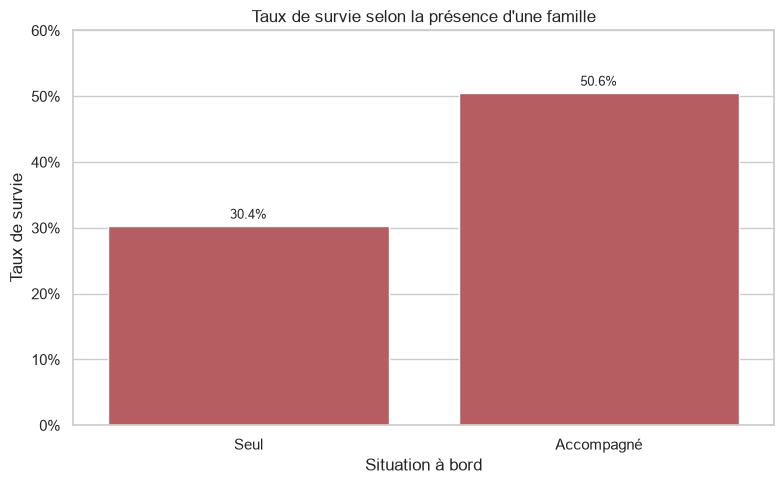

In [41]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=eda_df,
    x="IsAlone",
    y="Survived",
    order=["Seul", "Accompagné"],
    errorbar=None,
    color="#C44E52"
)

ax.set(
    title="Taux de survie selon la présence d'une famille",
    xlabel="Situation à bord",
    ylabel="Taux de survie"
)

ax.set_ylim(0, 0.6)
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda value, _: f"{value:.0%}")
)

add_percentage_labels(ax)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "survival_is_alone.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Regrouper les familles pour stabiliser l'analyse
Comme les familles très nombreuses sont rares. Il est préférable de les regrouper :

In [42]:
eda_df["FamilyGroup"] = pd.cut(
    eda_df["FamilySize"],
    bins=[0, 1, 4, 7, np.inf],
    labels=[
        "Seul",
        "Petite famille",
        "Famille moyenne",
        "Grande famille"
    ]
)

family_group_summary = survival_summary(eda_df, "FamilyGroup")
family_group_summary

,nombre_passagers,nombre_survivants,taux_survie
FamilyGroup,,,
Petite famille,292,169,57.88
Seul,537,163,30.35
Famille moyenne,49,10,20.41
Grande famille,13,0,0.00


#### Visualisation

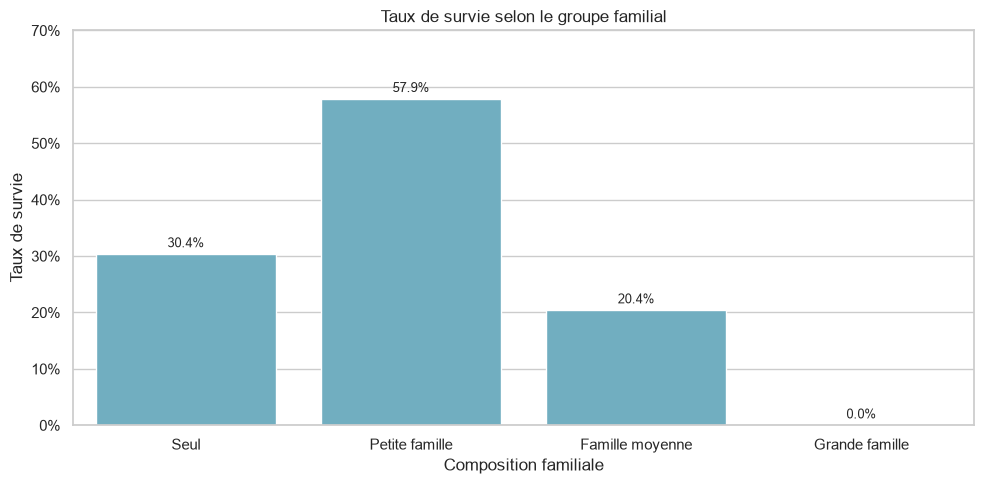

In [43]:
plt.figure(figsize=(10, 5))

family_order = [
    "Seul",
    "Petite famille",
    "Famille moyenne",
    "Grande famille"
]

ax = sns.barplot(
    data=eda_df,
    x="FamilyGroup",
    y="Survived",
    order=family_order,
    errorbar=None,
    color="#64B5CD"
)

ax.set(
    title="Taux de survie selon le groupe familial",
    xlabel="Composition familiale",
    ylabel="Taux de survie"
)

ax.set_ylim(0, 0.7)
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda value, _: f"{value:.0%}")
)

add_percentage_labels(ax)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "survival_by_family_group.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Conclusion
Les passagers voyageant seuls présentent un taux de survie inférieur à celui des
passagers accompagnés. Toutefois, la relation entre la taille familiale et la survie
n'est pas strictement linéaire : les petites familles semblent mieux représentées
parmi les survivants, tandis que les très grandes familles présentent de faibles taux
de survie.

Les variables `FamilySize` et `IsAlone` constituent donc des candidates pertinentes
pour le feature engineering.


---

## Extraction du titre des passagers

La variable `Name` est textuelle et contient de nombreuses valeurs uniques. Elle ne
sera pas utilisée directement. En revanche, le titre du passager peut fournir une
information sur son sexe, son âge, son statut marital ou son statut social.

In [44]:
eda_df["Title"] = (
    eda_df["Name"]
    .str.extract(r",\s*([^.]*)\.", expand=False)
    .str.strip()
)

eda_df["Title"].value_counts()

Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Major             2
Mlle              2
Col               2
Don               1
Mme               1
Ms                1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64

### Regroupement des titres rares

In [45]:
title_mapping = {
    "Mlle": "Miss",
    "Ms": "Miss",
    "Mme": "Mrs"
}

eda_df["TitleGrouped"] = eda_df["Title"].replace(title_mapping)

common_titles = ["Mr", "Miss", "Mrs", "Master"]

eda_df["TitleGrouped"] = eda_df["TitleGrouped"].where(
    eda_df["TitleGrouped"].isin(common_titles),
    "Rare"
)

eda_df["TitleGrouped"].value_counts()

TitleGrouped
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64

### Tableau et graphique

In [46]:
title_summary = survival_summary(eda_df, "TitleGrouped")
title_summary

,nombre_passagers,nombre_survivants,taux_survie
TitleGrouped,,,
Mrs,126,100,79.37
Miss,185,130,70.27
Master,40,23,57.50
Rare,23,8,34.78
Mr,517,81,15.67


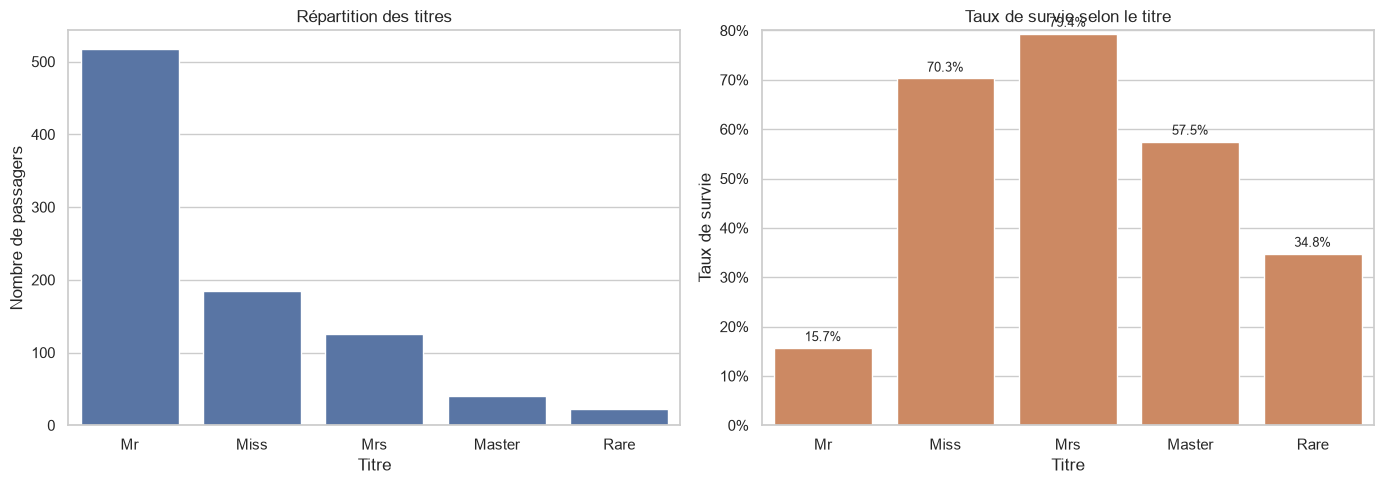

In [47]:
title_order = ["Mr", "Miss", "Mrs", "Master", "Rare"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(
    data=eda_df,
    x="TitleGrouped",
    order=title_order,
    color="#4C72B0",
    ax=axes[0]
)

axes[0].set(
    title="Répartition des titres",
    xlabel="Titre",
    ylabel="Nombre de passagers"
)

sns.barplot(
    data=eda_df,
    x="TitleGrouped",
    y="Survived",
    order=title_order,
    errorbar=None,
    color="#DD8452",
    ax=axes[1]
)

axes[1].set(
    title="Taux de survie selon le titre",
    xlabel="Titre",
    ylabel="Taux de survie"
)

axes[1].set_ylim(0, 0.8)
axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda value, _: f"{value:.0%}")
)

add_percentage_labels(axes[1])

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "title_analysis.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Vérification du lien entre titre et âge

In [48]:
title_age_summary = (
    eda_df
    .groupby("TitleGrouped")["Age"]
    .agg(["count", "mean", "median"])
    .round(2)
    .sort_values("median")
)

title_age_summary

,count,mean,median
TitleGrouped,,,
Master,36,4.57,3.5
Miss,149,21.85,21.0
Mr,398,32.37,30.0
Mrs,109,35.79,35.0
Rare,22,45.55,48.5


### Conclusion
Le titre extrait du nom résume plusieurs informations importantes. `Mr`, `Mrs` et
`Miss` sont notamment étroitement liés au sexe et au statut marital, tandis que
`Master` correspond généralement à de jeunes garçons.

Les taux de survie varient fortement entre les titres. Cette variable synthétique
pourrait être plus utile que le nom complet et pourrait également améliorer
l'imputation de l'âge.

---

## Analyse de la cabine et du pont

La variable `Cabin` contient de nombreuses valeurs manquantes. Plutôt que de la
supprimer immédiatement, nous étudions si la disponibilité d'une cabine ou son pont
apporte une information associée à la survie.

### Création des variables

In [49]:
eda_df["CabinKnown"] = np.where(
    eda_df["Cabin"].notna(),
    "Cabine renseignée",
    "Cabine inconnue"
)

eda_df["Deck"] = (
    eda_df["Cabin"]
    .str[0]
    .fillna("Unknown")
)

eda_df["Deck"].value_counts()

Deck
Unknown    687
C           59
B           47
D           33
E           32
A           15
F           13
G            4
T            1
Name: count, dtype: int64

### Présence de cabine

In [50]:
cabin_known_summary = survival_summary(eda_df, "CabinKnown")
cabin_known_summary

,nombre_passagers,nombre_survivants,taux_survie
CabinKnown,,,
Cabine renseignée,204,136,66.67
Cabine inconnue,687,206,29.99


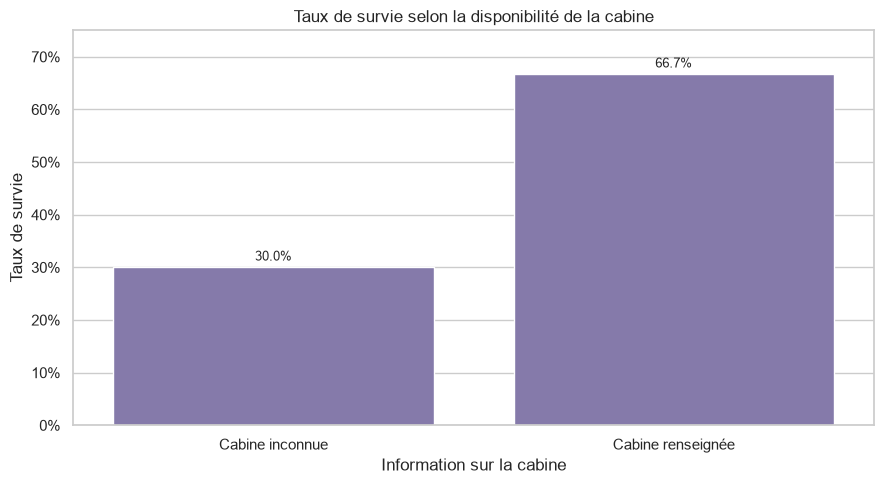

In [51]:
plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=eda_df,
    x="CabinKnown",
    y="Survived",
    order=["Cabine inconnue", "Cabine renseignée"],
    errorbar=None,
    color="#8172B2"
)

ax.set(
    title="Taux de survie selon la disponibilité de la cabine",
    xlabel="Information sur la cabine",
    ylabel="Taux de survie"
)

ax.set_ylim(0, 0.75)
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda value, _: f"{value:.0%}")
)

add_percentage_labels(ax)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "survival_by_cabin_availability.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Analyse du pont

In [52]:
deck_summary = survival_summary(eda_df, "Deck")
deck_summary

,nombre_passagers,nombre_survivants,taux_survie
Deck,,,
D,33,25,75.76
E,32,24,75.00
B,47,35,74.47
F,13,8,61.54
C,59,35,59.32
G,4,2,50.00
A,15,7,46.67
Unknown,687,206,29.99
T,1,0,0.00


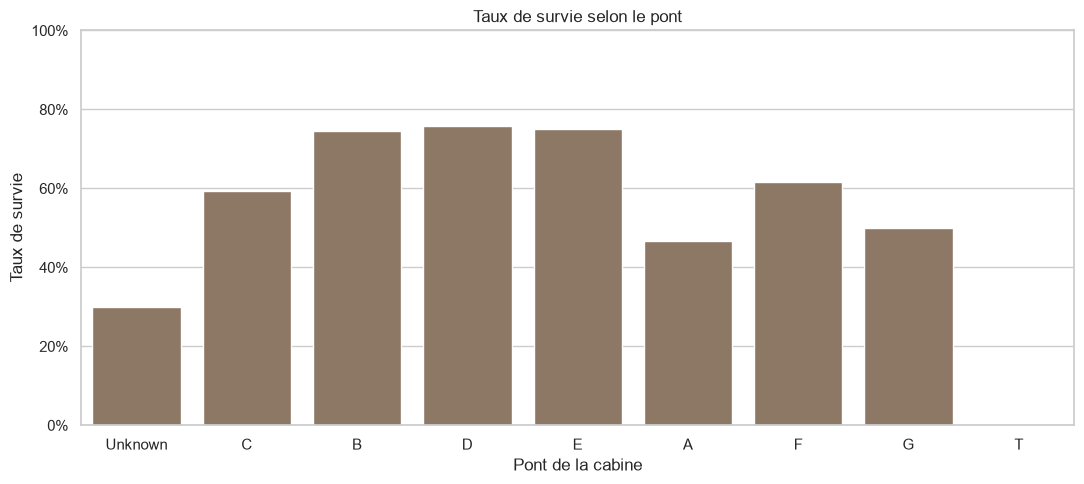

In [53]:
deck_order = (
    eda_df["Deck"]
    .value_counts()
    .index
    .tolist()
)

plt.figure(figsize=(11, 5))

ax = sns.barplot(
    data=eda_df,
    x="Deck",
    y="Survived",
    order=deck_order,
    errorbar=None,
    color="#937860"
)

ax.set(
    title="Taux de survie selon le pont",
    xlabel="Pont de la cabine",
    ylabel="Taux de survie"
)

ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda value, _: f"{value:.0%}")
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "survival_by_deck.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Conclusion
Les passagers dont la cabine est renseignée présentent un taux de survie supérieur à
ceux dont la cabine est inconnue. Cette observation peut cependant être en grande
partie liée à la classe du billet, les cabines étant davantage renseignées pour les
passagers des classes supérieures.

La colonne brute `Cabin` possède trop de modalités et trop de valeurs manquantes pour
être utilisée directement. En revanche, les variables `CabinKnown` et `Deck` pourront
être testées pendant le feature engineering.

---

## Corrélations entre les variables numériques

Une matrice de corrélation est utilisée pour observer les relations linéaires entre les
variables numériques. Les résultats doivent être interprétés avec prudence : une faible
corrélation linéaire n'implique pas qu'une variable soit inutile pour un modèle non
linéaire.

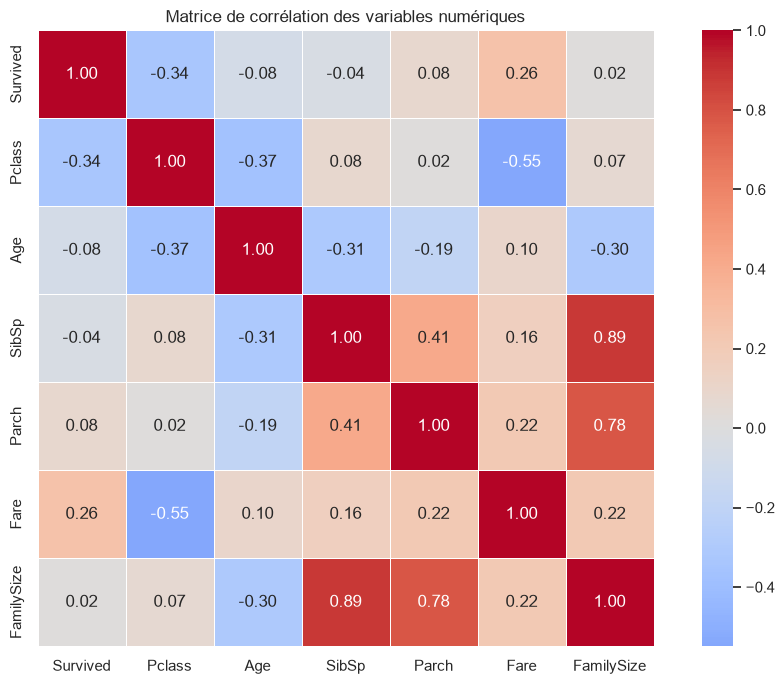

In [54]:
numeric_columns = [
    "Survived",
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "FamilySize"
]

correlation_matrix = (
    eda_df[numeric_columns]
    .corr()
)

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    square=True
)

plt.title("Matrice de corrélation des variables numériques")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "numeric_correlation_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Corrélation avec la cible

In [55]:
target_correlations = (
    correlation_matrix["Survived"]
    .drop("Survived")
    .sort_values(key=abs, ascending=False)
    .to_frame(name="correlation_with_survival")
)

target_correlations

,correlation_with_survival
Pclass,-0.338481
Fare,0.257307
Parch,0.081629
Age,-0.077221
SibSp,-0.035322
FamilySize,0.016639


### Conclusion
Parmi les variables numériques, la classe du billet et le tarif présentent des
associations notables avec la survie. `Pclass` possède une corrélation négative, car la
troisième classe est codée par une valeur numérique plus élevée que la première.

Ces corrélations ne décrivent que des relations linéaires et ne prennent pas en compte
les interactions. Elles ne doivent donc pas être utilisées seules pour sélectionner
les variables.


---

# Synthèse des variables

| Variable | Type | Traitement envisagé |
|---|---|---|
| `PassengerId` | Identifiant | Exclure du modèle |
| `Survived` | Cible binaire | Variable à prédire |
| `Pclass` | Catégorielle ordinale | Conserver ou encoder |
| `Sex` | Catégorielle nominale | One-hot encoding |
| `Age` | Numérique | Imputation par médiane, éventuellement selon le titre |
| `SibSp` | Numérique discrète | Conserver ou combiner |
| `Parch` | Numérique discrète | Conserver ou combiner |
| `Ticket` | Texte/catégorie | Étudier la taille des groupes |
| `Fare` | Numérique continue | Imputation et éventuellement `log1p` |
| `Cabin` | Catégorielle très incomplète | Extraire `Deck` et `CabinKnown` |
| `Embarked` | Catégorielle nominale | Imputation puis one-hot encoding |
| `Name` | Texte | Extraire le titre |
| `FamilySize` | Variable créée | `SibSp + Parch + 1` |
| `IsAlone` | Variable créée | Indique si le passager voyage seul |

---

# Conclusion de l'analyse exploratoire

L'analyse porte sur un problème de classification binaire visant à prédire la survie
des passagers du Titanic.

## Principaux constats

- La cible est modérément déséquilibrée : environ 38 % des passagers ont survécu.
- Le sexe est fortement associé à la survie : les femmes présentent un taux de survie
  nettement supérieur à celui des hommes.
- La classe du billet joue également un rôle important : les passagers de première
  classe ont davantage survécu que ceux de troisième classe.
- L'analyse conjointe du sexe et de la classe révèle des écarts importants entre les
  groupes, ce qui suggère la présence d'interactions utiles.
- Les enfants semblent bénéficier d'un taux de survie plus élevé que plusieurs groupes
  adultes, même si les distributions d'âge des survivants et des non-survivants se
  chevauchent largement.
- Les tarifs élevés sont davantage représentés parmi les survivants, mais cette
  relation est partiellement liée à la classe.
- Les passagers voyageant seuls et ceux appartenant à de très grandes familles
  présentent généralement de moins bons résultats.
- Le titre extrait du nom synthétise des informations relatives au sexe, à l'âge et au
  statut social.
- Malgré sa forte proportion de valeurs manquantes, la cabine peut fournir des
  variables utiles comme le pont ou la disponibilité de l'information.

## Qualité des données

- `Age`, `Cabin` et `Embarked` contiennent des valeurs manquantes dans le jeu
  d'entraînement.
- Le jeu de test contient également des valeurs manquantes, notamment dans `Age`,
  `Cabin` et `Fare`.
- `Cabin` ne sera pas utilisée directement en raison de son grand nombre de modalités
  et de valeurs absentes.
- `PassengerId` est un identifiant et ne sera pas utilisé comme caractéristique
  prédictive.

## Hypothèses pour la modélisation

Les variables suivantes semblent particulièrement pertinentes :

- `Sex` ;
- `Pclass` ;
- `Age` ;
- `Fare` ;
- `Embarked` ;
- `FamilySize` ;
- `IsAlone` ;
- `Title` ;
- `Deck` ;
- `CabinKnown`.

Toutes les opérations apprenant des paramètres à partir des données, comme l'imputation
et la standardisation, devront être ajustées uniquement sur les données
d'entraînement. Elles seront intégrées dans un pipeline Scikit-learn afin d'éviter les
fuites de données.

Ces résultats restent descriptifs. Les différences observées ne doivent pas être
interprétées comme des relations causales.